In [18]:
!pip install datasets -q

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete!")

Setup complete!


### Step 1: Load and Subset the Data
We will use `load_dataset("stanfordnlp/imdb")`. To save time and memory, we will only use the first 5,000 rows for training and 1,000 for testing.

In [19]:
# # Load the dataset
# dataset = load_dataset("stanfordnlp/imdb")

# # TODO: Extract the text (features) and labels from the train and test splits.
# # Subset them: take the first 5000 from train, and first 1000 from test.

# #I didnt take the initial data because it only consisted of only one y value.
# #I took intermediate range which had both values of y

# X_train = dataset['train']['text']
# y_train = dataset['train']['label']

# X_test = dataset['test']['text']
# y_test = dataset['test']['label']

# print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")
# # print((y_train[0]))

In [20]:
# Load the dataset
dataset = load_dataset("stanfordnlp/imdb")

# TODO: Extract the text (features) and labels from the train and test splits.
# Subset them: take the first 5000 from train, and first 1000 from test.
# the imdb dataset has continous 0s then continous 1s, hence,
# we shuffle the subset to ensure an even distribution of labels, making learning faster/viable.
train_subset = dataset['train'].shuffle(seed=42).select(range(5000)) # .shuffle and .select are 'lazy', i.e. they only perform their operation as you read the information one by one later on

X_train = train_subset['text']
y_train = train_subset['label']

test_subset = dataset['train'].shuffle(seed=42).select(range(1000))

X_test = test_subset['text']
y_test = test_subset['label']

print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")

Loaded 5000 training reviews and 1000 testing reviews.


### Step 2: Word to Math (TF-IDF)
Machines can't read English. We need to convert these text reviews into numbers using a `TfidfVectorizer`.

In [21]:
# TODO: Initialize the TfidfVectorizer. (Optional: limit max_features to 5000 to keep it fast)
vectorizer = TfidfVectorizer(max_features=5000)

# TODO: fit_transform the training data, and just transform the testing data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Data vectorized!")

Data vectorized!


In [22]:
#self exploration code block

# print(X_train_vec)
import numpy as np
print(np.unique(np.array(dataset['test']['label'][10000:15000])))
print(np.unique(np.array(dataset['train']['label'][12000:13000])))
print(len(dataset['test']['label']))
len(dataset['train']['label'])
print(len(train_subset['label']))


[0 1]
[0 1]
25000
5000


### Step 3: Train the Model
Time to train the Classical ML algorithm: Logistic Regression.

In [23]:
# TODO: Initialize LogisticRegression and fit it to your vectorized training data
model = LogisticRegression()
# Fit the model: model.fit(...)
model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


In [24]:
print(model)

LogisticRegression()


### Step 4: Evaluate
How good is your AI movie critic? Let's predict on the test set and calculate the metrics.

In [25]:
# TODO: Predict on X_test_vec
y_pred = model.predict(X_test_vec)

# TODO: Calculate and print the Accuracy and F1 Score
acc = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# TODO: Generate the confusion matrix and print it (Bonus points if you plot it using seaborn heatmap!)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print(type(cm))

Accuracy: 0.9310
F1 Score: 0.9291

Confusion Matrix:
[[479  33]
 [ 36 452]]
<class 'numpy.ndarray'>


<Axes: >

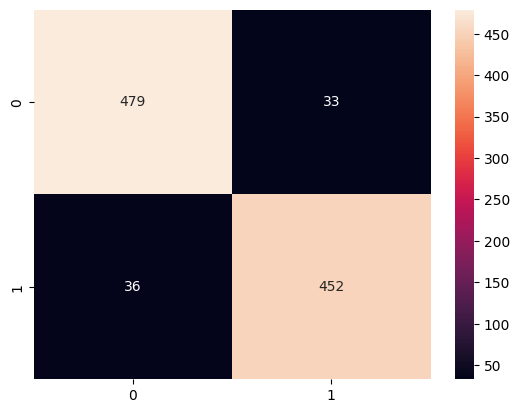

In [26]:
sns.heatmap(cm , annot = True , fmt='d')

In [27]:
tn,tp,fn,fp = 0,0,0,0

for i in range(len(y_pred)):
  if y_pred[i] == 0:
    if y_test[i] == 0:
      tn += 1
    else:
      fn += 1
  else:
    if y_test[i] == 1:
      tp += 1
    else:
      fp += 1

cm = [[tn,fp],[fn,tp]]
print(cm)

[[479, 33], [36, 452]]


In [28]:
def classify(review):
  x = vectorizer.transform([review])
  y = model.predict(x[0])

  if y == 1:
    print("Positive")
  else:
    print("Negative")

In [29]:
review = "great movie , would suggest watching."
classify(review)

review = "rubbish plot , zero efforts "
classify(review)

Positive
Negative
